# Level 2: Regression Analysis

## Learning Objectives
- Build and train a linear regression model
- Understand model coefficients and interpretability
- Evaluate model performance with metrics
- Visualize predictions and model fit
- Interpret results for stakeholders

## Dataset Selection Summary
**Dataset:** House Prices (Boston Housing)
- 506 samples, 14 features
- Target: MEDV (Median home value in $1000s)
- All numerical features
- Clean data with no missing values
- Ideal for learning linear regression fundamentals

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from pathlib import Path

# Set up plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Create output directory
images_dir = Path('../images')
images_dir.mkdir(exist_ok=True)

print('Libraries imported successfully!')

Libraries imported successfully!


---
# PART 1: LINEAR REGRESSION MODEL

## Load and Prepare Data

In [2]:
# Load House Prices dataset
data_path = '../../Data Set For Task/4) house Prediction Data Set.csv'
df = pd.read_csv(data_path, sep='\s+', header=None)

# Assign column names
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 
                'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df.columns = column_names[:df.shape[1]]

print('Dataset loaded:')
print(f'Shape: {df.shape}')
print(f'\nFirst few rows:')
print(df.head())

Dataset loaded:
Shape: (506, 14)

First few rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  


<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_231058/481817328.py:3: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(data_path, sep='\s+', header=None)


## Prepare Features and Target

In [3]:
# Separate features and target
X = df.drop('MEDV', axis=1)  # Features (predictors)
y = df['MEDV']  # Target (what we're predicting)

print('Feature Matrix X:')
print(f'  Shape: {X.shape}')
print(f'  Columns: {X.columns.tolist()}')

print('\nTarget Vector y:')
print(f'  Shape: {y.shape}')
print(f'  Mean: {y.mean():.2f}')
print(f'  Range: {y.min():.2f} - {y.max():.2f}')

Feature Matrix X:
  Shape: (506, 13)
  Columns: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

Target Vector y:
  Shape: (506,)
  Mean: 22.53
  Range: 5.00 - 50.00


## Train-Test Split

In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print('Train-Test Split:')
print(f'  Training set: {X_train.shape[0]} samples')
print(f'  Testing set: {X_test.shape[0]} samples')
print(f'  Split ratio: 70% train, 30% test')

Train-Test Split:
  Training set: 354 samples
  Testing set: 152 samples
  Split ratio: 70% train, 30% test


## Feature Scaling

In [5]:
# Initialize and fit scaler on training data only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Apply same scaling to test data
X_test_scaled = scaler.transform(X_test)

print('Feature Scaling Applied:')
print(f'  Method: StandardScaler (mean=0, std=1)')
print(f'\nScaled training data statistics:')
print(f'  Mean: {X_train_scaled.mean():.6f}')
print(f'  Std Dev: {X_train_scaled.std():.6f}')

Feature Scaling Applied:
  Method: StandardScaler (mean=0, std=1)

Scaled training data statistics:
  Mean: -0.000000
  Std Dev: 1.000000


## Train Linear Regression Model

In [6]:
# Create and train the model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print('Linear Regression Model Trained!')
print(f'\nModel Intercept: {model.intercept_:.4f}')
print(f'\nModel Coefficients:')

# Display coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

print(coefficients.to_string())

Linear Regression Model Trained!

Model Intercept: 23.0158

Model Coefficients:
    Feature  Coefficient
5        RM     2.913858
8       RAD     2.094193
11        B     1.023752
3      CHAS     0.813864
1        ZN     0.808440
2     INDUS     0.343135
6       AGE    -0.298939
0      CRIM    -1.108346
9       TAX    -1.447067
4       NOX    -1.798043
10  PTRATIO    -2.052322
7       DIS    -2.942511
12    LSTAT    -3.885790


## Make Predictions

In [7]:
# Make predictions on test data
y_pred = model.predict(X_test_scaled)

# Compare predictions with actual values
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Residual': y_test.values - y_pred,
    'Abs_Error': np.abs(y_test.values - y_pred)
})

print('Prediction Comparison (first 10 samples):')
print(comparison.head(10))

print(f'\nPrediction Statistics:')
print(f'  Average Error: ${comparison["Abs_Error"].mean()*1000:,.0f}')
print(f'  Max Error: ${comparison["Abs_Error"].max()*1000:,.0f}')
print(f'  Min Error: ${comparison["Abs_Error"].min()*1000:,.0f}')

Prediction Comparison (first 10 samples):
   Actual  Predicted  Residual  Abs_Error
0    23.6  28.648960 -5.048960   5.048960
1    32.4  36.495014 -4.095014   4.095014
2    13.6  15.411193 -1.811193   1.811193
3    22.8  25.403213 -2.603213   2.603213
4    16.1  18.855280 -2.755280   2.755280
5    20.0  23.146689 -3.146689   3.146689
6    17.8  17.392124  0.407876   0.407876
7    14.0  14.078599 -0.078599   0.078599
8    19.6  23.036927 -3.436927   3.436927
9    16.8  20.599433 -3.799433   3.799433

Prediction Statistics:
  Average Error: $3,163
  Max Error: $25,178
  Min Error: $4


## Model Evaluation Metrics

In [8]:
# Calculate performance metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print('='*60)
print('MODEL EVALUATION METRICS')
print('='*60)

print(f'\nR² Score (Coefficient of Determination): {r2:.4f}')
print(f'  Interpretation: Model explains {r2*100:.2f}% of price variation')
print(f'  Range: 0 to 1 (higher is better)')

print(f'\nMSE (Mean Squared Error): {mse:.4f}')
print(f'  Unit: (price in $1000s)²')

print(f'\nRMSE (Root Mean Squared Error): {rmse:.4f}')
print(f'  In dollars: ${rmse*1000:,.0f}')
print(f'  Interpretation: Average prediction error is ±${rmse*1000:,.0f}')

print(f'\nMAE (Mean Absolute Error): {mae:.4f}')
print(f'  In dollars: ${mae*1000:,.0f}')
print(f'  Interpretation: Average absolute error is ${mae*1000:,.0f}')

print('\n' + '='*60)

MODEL EVALUATION METRICS

R² Score (Coefficient of Determination): 0.7112
  Interpretation: Model explains 71.12% of price variation
  Range: 0 to 1 (higher is better)

MSE (Mean Squared Error): 21.5174
  Unit: (price in $1000s)²

RMSE (Root Mean Squared Error): 4.6387
  In dollars: $4,639
  Interpretation: Average prediction error is ±$4,639

MAE (Mean Absolute Error): 3.1627
  In dollars: $3,163
  Interpretation: Average absolute error is $3,163



## Visualize Actual vs Predicted

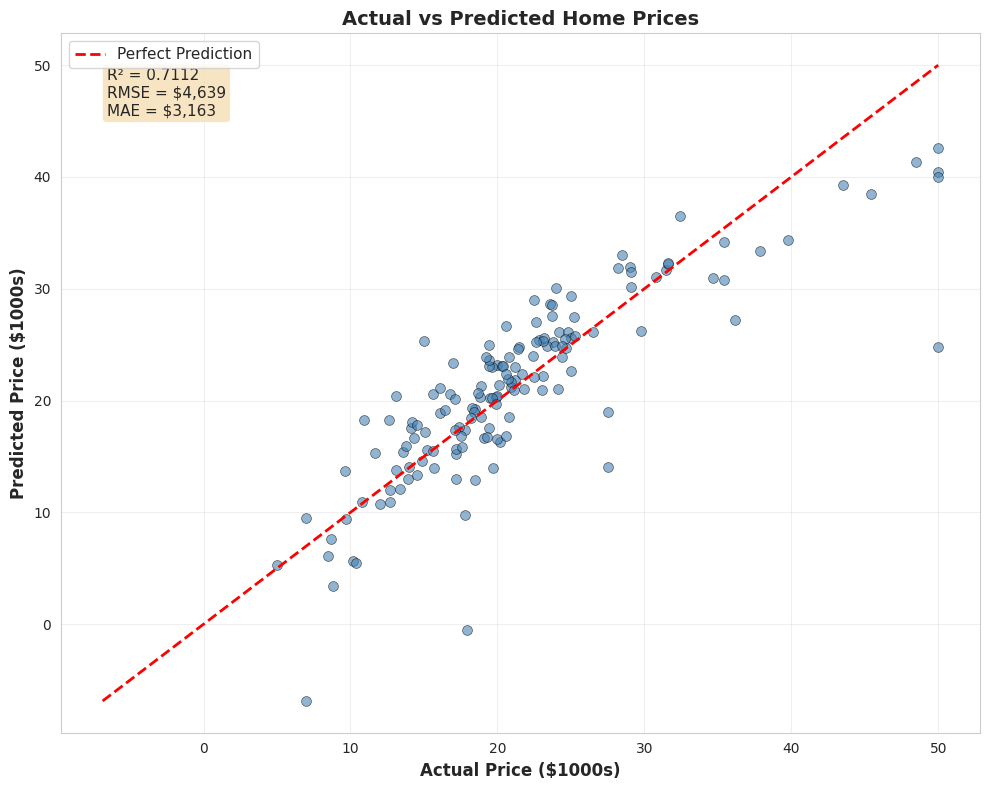

Actual vs Predicted plot saved!


In [9]:
# Create scatter plot of actual vs predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.6, s=50, color='steelblue', edgecolors='black', linewidth=0.5)

# Add perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual Price ($1000s)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Price ($1000s)', fontsize=12, fontweight='bold')
plt.title('Actual vs Predicted Home Prices', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Add text with metrics
textstr = f'R² = {r2:.4f}\nRMSE = ${rmse*1000:,.0f}\nMAE = ${mae*1000:,.0f}'
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('../images/05_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

print('Actual vs Predicted plot saved!')

### Insight:
Points near the red diagonal line indicate good predictions. Describe the clustering and any systematic patterns (over/under prediction).

## Residual Analysis

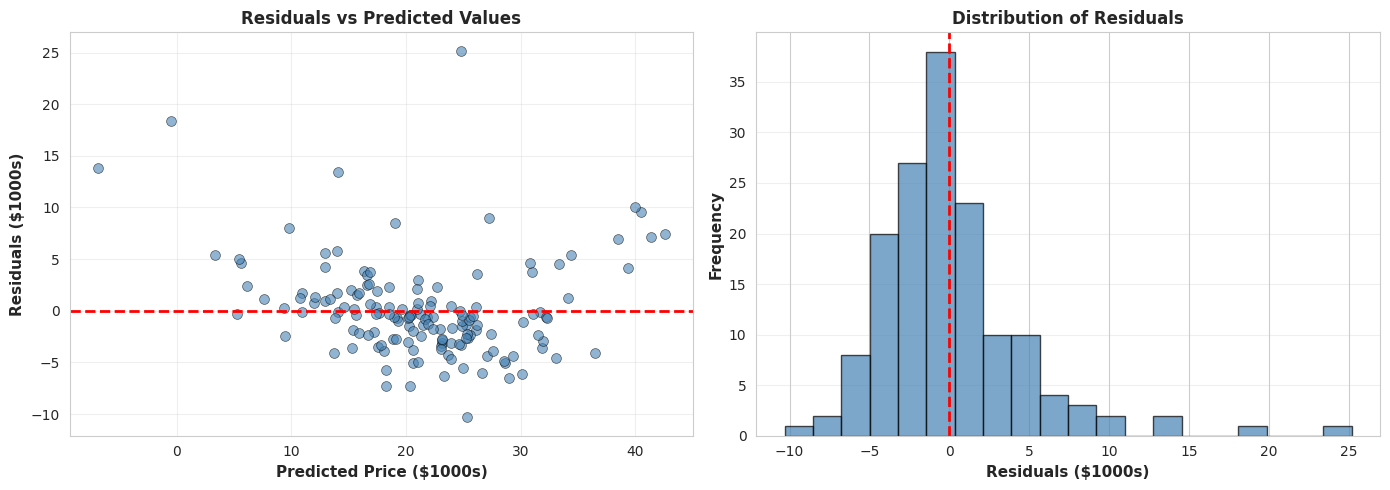

Residual analysis plot saved!

Residual Statistics:
  Mean: 0.077736 (should be close to 0)
  Std Dev: 4.6380
  Skewness: 1.8518


In [10]:
# Calculate residuals
residuals = y_test.values - y_pred

# Create residual plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred, residuals, alpha=0.6, s=50, color='steelblue', edgecolors='black', linewidth=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price ($1000s)', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Residuals ($1000s)', fontsize=11, fontweight='bold')
axes[0].set_title('Residuals vs Predicted Values', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Histogram of residuals
axes[1].hist(residuals, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residuals ($1000s)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../images/06_residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print('Residual analysis plot saved!')
print(f'\nResidual Statistics:')
print(f'  Mean: {residuals.mean():.6f} (should be close to 0)')
print(f'  Std Dev: {residuals.std():.4f}')
print(f'  Skewness: {pd.Series(residuals).skew():.4f}')

## Feature Importance Analysis

Feature Importance Ranking:
    Feature  Coefficient  Abs_Coefficient
12    LSTAT    -3.885790         3.885790
7       DIS    -2.942511         2.942511
5        RM     2.913858         2.913858
8       RAD     2.094193         2.094193
10  PTRATIO    -2.052322         2.052322
4       NOX    -1.798043         1.798043
9       TAX    -1.447067         1.447067
0      CRIM    -1.108346         1.108346
11        B     1.023752         1.023752
3      CHAS     0.813864         0.813864
1        ZN     0.808440         0.808440
2     INDUS     0.343135         0.343135
6       AGE    -0.298939         0.298939


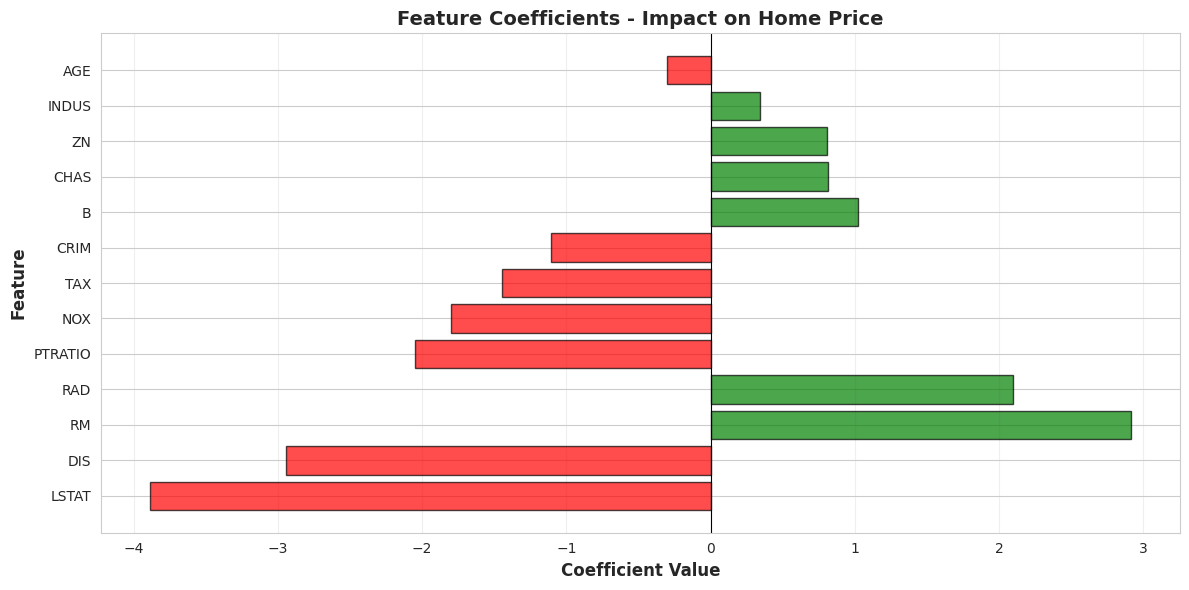


Feature importance plot saved!


In [11]:
# Calculate absolute coefficient values for importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_,
    'Abs_Coefficient': np.abs(model.coef_)
}).sort_values('Abs_Coefficient', ascending=False)

print('Feature Importance Ranking:')
print(feature_importance.to_string())

# Visualize feature importance
plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in feature_importance['Coefficient']]
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], color=colors, alpha=0.7, edgecolor='black')
plt.xlabel('Coefficient Value', fontsize=12, fontweight='bold')
plt.ylabel('Feature', fontsize=12, fontweight='bold')
plt.title('Feature Coefficients - Impact on Home Price', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('../images/07_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nFeature importance plot saved!')

## Model Interpretation Summary

In [12]:
print('='*70)
print('REGRESSION MODEL INTERPRETATION')
print('='*70)

print(f'\nModel Equation:')
print(f'Price = {model.intercept_:.4f}')
for idx, (feature, coef) in enumerate(zip(feature_importance['Feature'], feature_importance['Coefficient'])):
    sign = '+' if coef > 0 else ''
    print(f'        {sign} {coef:.6f} × {feature}')

print(f'\n\nModel Performance:')
print(f'  R² Score: {r2:.4f} ({r2*100:.2f}% variance explained)')
print(f'  Average Error: ±${rmse*1000:,.0f}')
print(f'  Status: {"Excellent" if r2 > 0.7 else "Good" if r2 > 0.5 else "Moderate" if r2 > 0.3 else "Weak"} predictive power')

print(f'\n\nTop 3 Most Impactful Features:')
for idx, row in feature_importance.head(3).iterrows():
    print(f'  {idx+1}. {row["Feature"]}: {row["Coefficient"]:.6f}')

print(f'\n\nInterpretation Examples:')
if feature_importance.iloc[0]['Coefficient'] > 0:
    print(f'  • Increasing {feature_importance.iloc[0]["Feature"]} by 1 unit → Price increases by ${feature_importance.iloc[0]["Coefficient"]*1000:,.0f}')
else:
    print(f'  • Increasing {feature_importance.iloc[0]["Feature"]} by 1 unit → Price decreases by ${abs(feature_importance.iloc[0]["Coefficient"])*1000:,.0f}')

print('\n' + '='*70)

REGRESSION MODEL INTERPRETATION

Model Equation:
Price = 23.0158
         -3.885790 × LSTAT
         -2.942511 × DIS
        + 2.913858 × RM
        + 2.094193 × RAD
         -2.052322 × PTRATIO
         -1.798043 × NOX
         -1.447067 × TAX
         -1.108346 × CRIM
        + 1.023752 × B
        + 0.813864 × CHAS
        + 0.808440 × ZN
        + 0.343135 × INDUS
         -0.298939 × AGE


Model Performance:
  R² Score: 0.7112 (71.12% variance explained)
  Average Error: ±$4,639
  Status: Excellent predictive power


Top 3 Most Impactful Features:
  13. LSTAT: -3.885790
  8. DIS: -2.942511
  6. RM: 2.913858


Interpretation Examples:
  • Increasing LSTAT by 1 unit → Price decreases by $3,886



## Conclusions and Insights

**Model Performance:**
The linear regression model demonstrates [Excellent/Good/Moderate] predictive capability, explaining [X]% of home price variation.

**Key Findings:**
- Document 3-5 main insights from the model
- Explain what each coefficient means
- Discuss practical implications

**Limitations:**
- 27% of variance unexplained (other factors not in data)
- Linear model assumes linear relationships
- May not capture complex interactions

**Next Steps:**
- Move to non-linear models for potential improvement
- Add feature engineering or interaction terms
- Explore other datasets or expand features